# Notebook 1: Support Ticket Data Generation, Cleaning, and Exploratory Analysis

## Project
**Automating Support Ticket Routing with NLP**

## Notebook objective
This notebook creates a realistic synthetic support ticket dataset for an NLP-based ticket routing project. It then cleans the data, explores its structure, and saves both raw and cleaned versions for downstream modeling.

## Why this notebook matters
In many support operations, incoming tickets are manually reviewed and assigned to teams such as billing, technical support, account access, or refunds. This manual triage process can be slow, inconsistent, and difficult to scale.

This notebook builds the foundation for an automated routing system by:
- generating realistic support tickets across multiple business teams
- introducing practical data quality issues such as duplicates and missing values
- cleaning and standardizing the dataset
- exploring the target classes and text characteristics

## Outputs
By the end of this notebook, we will have:
- a raw synthetic ticket dataset
- a cleaned ticket dataset ready for feature engineering
- exploratory analysis plots and summary tables

In [1]:
from pathlib import Path
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Project directories

We first create a simple folder structure so the notebook can save:
- the raw dataset
- the cleaned dataset
- any outputs produced during analysis

In [2]:
BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data folder:", RAW_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Figures folder:", FIGURES_DIR)

Raw data folder: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\raw
Processed data folder: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\processed
Figures folder: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\figures


## Define routing classes and issue themes

The project predicts the dominant team that should handle a ticket.

### Routed teams
- Technical Support
- Billing
- Account Access
- Orders & Delivery
- Refunds & Returns
- Product Inquiry

### Important design principle
To make the task more realistic, this notebook does **not** give each class a completely separate vocabulary.

Instead:
- several issue themes share overlapping words
- some tickets mention multiple issue types
- the final label reflects the dominant handling team, not necessarily the only issue mentioned

In [3]:
ROUTED_TEAMS = [
    "Technical Support",
    "Billing",
    "Account Access",
    "Orders & Delivery",
    "Refunds & Returns",
    "Product Inquiry"
]

TEAM_WEIGHTS = {
    "Technical Support": 0.24,
    "Billing": 0.17,
    "Account Access": 0.16,
    "Orders & Delivery": 0.15,
    "Refunds & Returns": 0.15,
    "Product Inquiry": 0.13
}

CUSTOMER_TIERS = ["Free", "Basic", "Pro", "Enterprise"]
CUSTOMER_TIER_WEIGHTS = [0.18, 0.32, 0.30, 0.20]

CHANNELS = ["email", "chat", "web_form", "phone"]
CHANNEL_WEIGHTS = [0.38, 0.24, 0.24, 0.14]

LANGUAGES = ["English", "English", "English", "English", "English", "French", "Spanish"]
STATUS_OPTIONS = ["Open", "Pending", "Resolved"]
STATUS_WEIGHTS = [0.50, 0.22, 0.28]

PRODUCT_AREAS = [
    "Web App",
    "Mobile App",
    "Customer Portal",
    "Admin Console",
    "API",
    "Analytics Dashboard",
    "Invoice Portal",
    "Starter Kit",
    "Premium Device",
    "Replacement Unit",
    "Subscription Plan",
    "Data Export"
]

## Define realistic issue pools

Each issue pool represents a common type of support problem.

A ticket may contain:
- one main issue
- one secondary issue
- a generic context sentence
- a vague subject line
- extra business context such as urgency or customer frustration

This creates overlap across classes.

In [4]:
ISSUE_POOLS = {
    "Technical Support": {
        "keywords": [
            "error", "bug", "not loading", "timeout", "crash",
            "sync problem", "failed export", "system issue", "unexpected behaviour"
        ],
        "sentences": [
            "The system keeps showing an error when I try to continue.",
            "The page is not loading properly and I cannot complete the task.",
            "This was working before but now it keeps failing.",
            "I am seeing unexpected behaviour in the product.",
            "The app crashes when I try to use this feature.",
            "I cannot complete the workflow because something keeps breaking.",
            "The export fails halfway through and I do not know why.",
            "The issue seems technical because the same step keeps timing out."
        ]
    },
    "Billing": {
        "keywords": [
            "charge", "invoice", "payment", "billing issue", "double charge",
            "unexpected fee", "renewal", "amount looks wrong", "payment failed"
        ],
        "sentences": [
            "I think I was charged incorrectly for this.",
            "The invoice does not look right to me.",
            "There seems to be a problem with the payment on my account.",
            "I noticed an unexpected charge and need clarification.",
            "The renewal amount looks different from what I expected.",
            "I am not sure why this payment failed.",
            "I need someone to review the billing on this account.",
            "The amount shown on the invoice looks wrong."
        ]
    },
    "Account Access": {
        "keywords": [
            "login", "password reset", "locked out", "cannot sign in",
            "authentication problem", "2fa", "access issue", "verification failed"
        ],
        "sentences": [
            "I cannot sign in to my account at the moment.",
            "The password reset process is not working.",
            "I appear to be locked out and cannot get back in.",
            "The login step keeps failing even though my details should be correct.",
            "Authentication is not going through on my side.",
            "I still cannot access the portal after trying several times.",
            "The verification step is failing and I need help.",
            "This looks like an account access problem."
        ]
    },
    "Orders & Delivery": {
        "keywords": [
            "delivery", "tracking", "shipment", "package", "order not arrived",
            "delay", "wrong item", "dispatch issue", "missing order"
        ],
        "sentences": [
            "My order has still not arrived.",
            "Tracking has not updated in a while.",
            "There seems to be a delay with the shipment.",
            "I think the wrong item was sent.",
            "The package is missing and I need an update.",
            "Delivery is taking longer than expected.",
            "I cannot tell where the order currently is.",
            "There appears to be an issue with the dispatch."
        ]
    },
    "Refunds & Returns": {
        "keywords": [
            "refund", "return", "money back", "damaged item",
            "return request", "refund status", "replacement", "not as expected"
        ],
        "sentences": [
            "I would like a refund for this order.",
            "I need to return the item because it is not as expected.",
            "The product arrived damaged and I need help with next steps.",
            "I have not had an update on my refund yet.",
            "I want to know the status of the return request.",
            "I need my money back if this cannot be resolved.",
            "The item is damaged so I may need a replacement or refund.",
            "I am trying to return this purchase."
        ]
    },
    "Product Inquiry": {
        "keywords": [
            "pricing", "feature", "compatibility", "plan options",
            "difference between plans", "how it works", "before purchase", "information request"
        ],
        "sentences": [
            "I need more information before making a decision.",
            "Can you explain how this feature works?",
            "I want to understand the pricing options better.",
            "I am comparing plans and need clarification.",
            "I am not sure whether this product supports my use case.",
            "Could you explain the difference between the available options?",
            "This is more of a general product question.",
            "I need help understanding whether this is compatible with my setup."
        ]
    }
}

## Define overlap rules and mixed-intent combinations

Real support tickets often contain more than one issue.

For example:
- a customer may mention a delayed order and ask for a refund
- a user may be unable to log in and also ask about a billing issue
- a damaged item may lead to both returns and shipping language

These combinations make the classification task more realistic.

In [5]:
SECONDARY_ISSUE_PROBS = {
    "Technical Support": {
        "Account Access": 0.22,
        "Billing": 0.10,
        "Product Inquiry": 0.08
    },
    "Billing": {
        "Refunds & Returns": 0.22,
        "Account Access": 0.10,
        "Product Inquiry": 0.08,
        "Orders & Delivery": 0.08
    },
    "Account Access": {
        "Technical Support": 0.20,
        "Billing": 0.12,
        "Product Inquiry": 0.06
    },
    "Orders & Delivery": {
        "Refunds & Returns": 0.30,
        "Billing": 0.08,
        "Product Inquiry": 0.05
    },
    "Refunds & Returns": {
        "Orders & Delivery": 0.28,
        "Billing": 0.12,
        "Technical Support": 0.06
    },
    "Product Inquiry": {
        "Billing": 0.12,
        "Technical Support": 0.08,
        "Account Access": 0.05
    }
}

GENERIC_SUBJECTS = [
    "Need help with my account",
    "Issue with recent order",
    "Please check this",
    "Need support urgently",
    "Can someone help",
    "Question about my account",
    "Problem with service",
    "Issue not resolved",
    "Need an update",
    "Help needed",
    "Support request",
    "Problem with recent activity"
]

SPECIFIC_SUBJECT_PATTERNS = [
    "Problem with {product_area}",
    "Issue with {keyword}",
    "Need help with {product_area}",
    "Question about {product_area}",
    "{keyword} on my account",
    "Need an update on this issue",
    "Please review this request",
    "Follow-up on my previous issue"
]

OPENING_LINES = [
    "Hi team,",
    "Hello,",
    "Hi,",
    "Good morning,",
    "Can someone help with this?",
    "I need help with something.",
    "This has become a problem for me."
]

CLOSING_LINES = [
    "Please advise.",
    "Please let me know what I should do next.",
    "Any help would be appreciated.",
    "This is becoming urgent.",
    "I would appreciate a quick response.",
    "Please look into this.",
    "Thanks."
]

URGENCY_LINES = [
    "This is affecting my work today.",
    "I need this resolved as soon as possible.",
    "I have already tried a few times with no success.",
    "This has been going on since yesterday.",
    "I was hoping this would be fixed by now.",
    "This is quite frustrating."
]

CONTEXT_LINES = [
    "I am using the service on mobile.",
    "I am using the web version.",
    "This started after my last purchase.",
    "This happened shortly after I updated my details.",
    "I noticed this after trying to make a payment.",
    "This seems linked to my recent order.",
    "I only need a clear update on what is happening.",
    "I do not know if this should go to billing or support."
]

## Create helper functions for realistic generation

These helper functions are used to:
- sample dominant and secondary issue types
- generate more varied subjects
- assemble multi-sentence descriptions
- inject realistic text noise
- simulate timestamps and IDs

The aim is to avoid obvious one-template-per-class patterns.

In [6]:
def weighted_choice(mapping):
    keys = list(mapping.keys())
    weights = list(mapping.values())
    return random.choices(keys, weights=weights, k=1)[0]

def maybe_secondary_issue(primary_team):
    options = SECONDARY_ISSUE_PROBS.get(primary_team, {})
    if not options:
        return None

    trigger = random.random()
    if trigger < 0.40:
        return weighted_choice(options)
    return None

TYPO_MAP = {
    "account": "acount",
    "password": "passwrod",
    "billing": "biling",
    "support": "suport",
    "issue": "isue",
    "delivery": "delivry",
    "refund": "refnd",
    "problem": "probem",
    "because": "becuase",
    "working": "workng",
    "please": "pls"
}

def inject_typo(text):
    lower_text = text.lower()
    possible = [k for k in TYPO_MAP if k in lower_text]
    if not possible:
        return text

    chosen = random.choice(possible)
    pattern = re.compile(re.escape(chosen), flags=re.IGNORECASE)
    return pattern.sub(TYPO_MAP[chosen], text, count=1)

def add_noise(text, is_subject=False):
    if random.random() < 0.16:
        text = re.sub(r"\s+", "  ", text)

    if random.random() < 0.12:
        text = inject_typo(text)

    if random.random() < 0.06:
        text = text.upper()

    if random.random() < 0.08 and is_subject:
        text = "URGENT - " + text

    if random.random() < 0.05 and is_subject:
        text = text.rstrip(".!?")

    if random.random() < 0.08 and not is_subject:
        text = text.replace("Please", "please")

    return text

def generate_created_at():
    start = pd.Timestamp("2025-01-01")
    end = pd.Timestamp("2025-12-31 23:59:59")
    total_seconds = int((end - start).total_seconds())
    return start + pd.to_timedelta(random.randint(0, total_seconds), unit="s")

def choose_product_area(primary_team, secondary_team=None):
    if primary_team in ["Orders & Delivery", "Refunds & Returns"]:
        candidates = ["Starter Kit", "Premium Device", "Replacement Unit"]
    elif primary_team in ["Billing"]:
        candidates = ["Invoice Portal", "Subscription Plan", "Customer Portal"]
    elif primary_team in ["Account Access"]:
        candidates = ["Customer Portal", "Admin Console", "Mobile App", "Web App"]
    elif primary_team in ["Technical Support"]:
        candidates = ["Web App", "Mobile App", "API", "Analytics Dashboard", "Data Export"]
    else:
        candidates = PRODUCT_AREAS

    if secondary_team == "Orders & Delivery":
        candidates = candidates + ["Starter Kit", "Premium Device"]
    if secondary_team == "Refunds & Returns":
        candidates = candidates + ["Replacement Unit", "Premium Device"]
    if secondary_team == "Billing":
        candidates = candidates + ["Invoice Portal", "Subscription Plan"]

    return random.choice(candidates)

def choose_priority(primary_team, secondary_team=None):
    base = {
        "Technical Support": {"Low": 0.10, "Medium": 0.50, "High": 0.40},
        "Billing": {"Low": 0.18, "Medium": 0.56, "High": 0.26},
        "Account Access": {"Low": 0.10, "Medium": 0.40, "High": 0.50},
        "Orders & Delivery": {"Low": 0.22, "Medium": 0.56, "High": 0.22},
        "Refunds & Returns": {"Low": 0.18, "Medium": 0.50, "High": 0.32},
        "Product Inquiry": {"Low": 0.44, "Medium": 0.44, "High": 0.12}
    }

    probs = base[primary_team].copy()

    if secondary_team in ["Refunds & Returns", "Account Access", "Technical Support"]:
        probs["High"] += 0.05
        probs["Low"] -= 0.03
        probs["Medium"] -= 0.02

    total = sum(probs.values())
    probs = {k: v / total for k, v in probs.items()}
    return weighted_choice(probs)

In [7]:
def generate_subject(primary_team, product_area, primary_keyword, secondary_keyword=None):
    if random.random() < 0.45:
        subject = random.choice(GENERIC_SUBJECTS)
    else:
        pattern = random.choice(SPECIFIC_SUBJECT_PATTERNS)
        keyword = primary_keyword if random.random() < 0.75 else (secondary_keyword or primary_keyword)
        subject = pattern.format(product_area=product_area, keyword=keyword)

    if random.random() < 0.10:
        subject = subject + " " + random.choice(["again", "still", "today", "please"])

    return add_noise(subject, is_subject=True)

def generate_description(primary_team, secondary_team, product_area):
    primary_pool = ISSUE_POOLS[primary_team]
    primary_sentence = random.choice(primary_pool["sentences"])
    primary_keyword = random.choice(primary_pool["keywords"])

    sentences = []

    if random.random() < 0.70:
        sentences.append(random.choice(OPENING_LINES))

    sentences.append(primary_sentence)

    if random.random() < 0.45:
        sentences.append(f"It involves {product_area.lower()} on my side.")

    if secondary_team is not None:
        secondary_pool = ISSUE_POOLS[secondary_team]
        secondary_sentence = random.choice(secondary_pool["sentences"])

        bridge_patterns = [
            f"In addition, {secondary_sentence[0].lower() + secondary_sentence[1:]}",
            f"Also, {secondary_sentence[0].lower() + secondary_sentence[1:]}",
            f"At the same time, {secondary_sentence[0].lower() + secondary_sentence[1:]}",
            f"This may also be related because {secondary_sentence[0].lower() + secondary_sentence[1:]}"
        ]
        sentences.append(random.choice(bridge_patterns))

    if random.random() < 0.42:
        sentences.append(random.choice(CONTEXT_LINES))

    if random.random() < 0.38:
        sentences.append(random.choice(URGENCY_LINES))

    if random.random() < 0.68:
        sentences.append(random.choice(CLOSING_LINES))

    description = " ".join(sentences)
    description = re.sub(r"\s+", " ", description).strip()
    description = add_noise(description, is_subject=False)

    secondary_keyword = None
    if secondary_team is not None:
        secondary_keyword = random.choice(ISSUE_POOLS[secondary_team]["keywords"])

    return description, primary_keyword, secondary_keyword

## Generate individual tickets with dominant-intent routing

Each ticket is assigned:
- a dominant routed team
- optionally a secondary issue
- realistic metadata
- a subject and description that may contain overlapping signals

This makes the label realistic without making the text perfectly separable.

In [8]:
def generate_ticket(ticket_num):
    primary_team = weighted_choice(TEAM_WEIGHTS)
    secondary_team = maybe_secondary_issue(primary_team)

    product_area = choose_product_area(primary_team, secondary_team)
    customer_tier = random.choices(CUSTOMER_TIERS, weights=CUSTOMER_TIER_WEIGHTS, k=1)[0]
    channel = random.choices(CHANNELS, weights=CHANNEL_WEIGHTS, k=1)[0]
    language = random.choice(LANGUAGES)
    status = random.choices(STATUS_OPTIONS, weights=STATUS_WEIGHTS, k=1)[0]
    priority = choose_priority(primary_team, secondary_team)

    description, primary_keyword, secondary_keyword = generate_description(
        primary_team=primary_team,
        secondary_team=secondary_team,
        product_area=product_area
    )

    subject = generate_subject(
        primary_team=primary_team,
        product_area=product_area,
        primary_keyword=primary_keyword,
        secondary_keyword=secondary_keyword
    )

    ticket = {
        "ticket_id": f"TKT-{ticket_num:06d}",
        "created_at": generate_created_at(),
        "channel": channel,
        "customer_tier": customer_tier,
        "language": language,
        "product_area": product_area,
        "subject": subject,
        "description": description,
        "routed_team": primary_team,
        "secondary_issue_team": secondary_team if secondary_team is not None else "None",
        "priority": priority,
        "status": status
    }
    return ticket

## Generate the raw dataset

We now generate the base dataset and then deliberately introduce:
- duplicate-like records
- missing values
- non-standard missing markers
- slight text variations
- incomplete metadata

These are common in real operational support data.

In [9]:
N_TICKETS = 3600

raw_records = [generate_ticket(i) for i in range(1, N_TICKETS + 1)]
raw_df = pd.DataFrame(raw_records)

print("Initial generated shape:", raw_df.shape)
raw_df.head()

Initial generated shape: (3600, 12)


,ticket_id,created_at,channel,customer_tier,language,product_area,subject,description,routed_team,secondary_issue_team,priority,status
0,TKT-000001,2025-02-18 11:27:50,email,Free,French,Premium Device,Question about my account,"HELLO, I CANNOT TELL WHERE THE ORDER CURRENTLY IS. IT INVOLVES PREMIUM DEVICE ON MY SIDE. ALSO, I WOULD LIKE A REFUND FOR THIS ORDER. THIS IS BECOMING URGENT.",Orders & Delivery,Refunds & Returns,Low,Resolved
1,TKT-000002,2025-06-05 19:07:36,phone,Pro,English,Subscription Plan,URGENT - Support request,I am comparing plans and need clarification. This may also be related because the page is not loading properly and I cannot complete the task. This seems li...,Product Inquiry,Technical Support,Low,Open
2,TKT-000003,2025-01-02 06:14:54,chat,Basic,French,Customer Portal,Problem with Customer Portal,"I need help with something. I noticed an unexpected charge and need clarification. At the same time, i cannot tell where the order currently is. This starte...",Billing,Orders & Delivery,Medium,Open
3,TKT-000004,2025-09-14 05:19:24,web_form,Enterprise,English,API,Need suport urgently,This has become a problem for me. I am not sure whether this product supports my use case. It involves api on my side.,Product Inquiry,None,Medium,Resolved
4,TKT-000005,2025-08-10 18:30:26,chat,Pro,English,Mobile App,Need help with my account,I need help with something. The login step keeps failing even though my details should be correct. pls let me know what I should do ...,Account Access,None,High,Resolved


In [10]:
# Add duplicate-like tickets
dup_n = int(len(raw_df) * 0.05)
dup_rows = raw_df.sample(dup_n, random_state=SEED).copy()

dup_rows["ticket_id"] = [f"TKT-DUP-{i:05d}" for i in range(1, dup_n + 1)]
dup_rows["created_at"] = dup_rows["created_at"] + pd.to_timedelta(
    np.random.randint(60, 10800, size=dup_n), unit="s"
)

for idx in dup_rows.sample(frac=0.50, random_state=SEED).index:
    text = str(dup_rows.loc[idx, "description"])
    addition = random.choice([
        " Please advise.",
        " Can someone update me?",
        " I need help with this.",
        " This is still unresolved.",
        " Kindly check this."
    ])
    dup_rows.loc[idx, "description"] = text + addition

# Inject missing values
missing_probs = {
    "channel": 0.025,
    "customer_tier": 0.030,
    "product_area": 0.020,
    "subject": 0.018,
    "description": 0.025,
    "secondary_issue_team": 0.015
}

for col, prob in missing_probs.items():
    mask = np.random.rand(len(raw_df)) < prob
    raw_df.loc[mask, col] = np.nan

# Inject non-standard missing markers
nonstandard_markers = ["-", "missing", "N/A"]
for col in ["channel", "customer_tier", "product_area"]:
    mask = np.random.rand(len(raw_df)) < 0.015
    raw_df.loc[mask, col] = np.random.choice(nonstandard_markers, size=mask.sum())

raw_df = pd.concat([raw_df, dup_rows], ignore_index=True)
raw_df = raw_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Raw dataset with noise shape:", raw_df.shape)
raw_df.head(10)

Raw dataset with noise shape: (3780, 12)


,ticket_id,created_at,channel,customer_tier,language,product_area,subject,description,routed_team,secondary_issue_team,priority,status
0,TKT-000839,2025-09-27 20:43:18,chat,Pro,French,Customer Portal,compatibility on my account,"CAN SOMEONE HELP WITH THIS? CAN YOU EXPLAIN HOW THIS FEATURE WORKS? AT THE SAME TIME, THE RENEWAL AMOUNT LOOKS DIFFERENT FROM WHAT I EXPECTED. I ONLY NEED A...",Product Inquiry,Billing,Low,Resolved
1,TKT-002616,2025-07-26 18:57:56,chat,Basic,English,Subscription Plan,Need an update on this issue,"Good morning, The invoice does not look right to me. It involves subscription plan on my side. I only need a clear update on what is happening. I would appr...",Billing,None,Medium,Open
2,TKT-000872,2025-05-12 04:54:19,email,Enterprise,English,Subscription Plan,Problem with Subscription Plan,"Hello, I am not sure whether this product supports my use case. It involves subscription plan on my side. I only need a clear update on what is happening. T...",Product Inquiry,None,Medium,Open
3,TKT-002803,2025-11-03 13:00:21,web_form,Pro,English,Customer Portal,Issue with amount looks wrong,Can someone help with this? There seems to be a problem with the payment on my account. Please let me know what I should do next.,Billing,None,Medium,Resolved
4,TKT-001189,2025-10-26 15:32:56,chat,Enterprise,English,Invoice Portal,Can someone help,"Good morning, I noticed an unexpected charge and need clarification. It involves invoice portal on my side. I am using the service on mobile. Please look in...",Billing,None,High,Open
5,TKT-000241,2025-02-03 19:44:11,web_form,Pro,English,Starter Kit,refund on my account,This has become a problem for me. I need my money back if this cannot be resolved. It involves starter kit on my side. This may also be related because deli...,Refunds & Returns,Orders & Delivery,High,Resolved
6,TKT-002078,2025-10-05 23:03:01,phone,Free,English,Starter Kit,Question about my account,Can someone help with this? I think the wrong item was sent. I need this resolved as soon as possible. I would appreciate a quick response.,Orders & Delivery,None,Medium,Open
7,TKT-001316,2025-08-02 06:07:21,phone,Pro,French,Admin Console,Support request,This looks like an account access problem. This may also be related because this was working before but now it keeps failing. This ha...,Account Access,Technical Support,Low,Resolved
8,TKT-003527,2025-03-02 22:34:15,chat,Pro,English,Customer Portal,NEED HELP WITH CUSTOMER PORTAL,The password reset process is not working. This started after my last purchase. I have already tried a few times with no success. Ple...,Account Access,None,Medium,Open
9,TKT-000415,2025-06-29 03:30:15,chat,NaN,English,Starter Kit,compatibility on my account,Can someone help with this? I am not sure whether this product supports my use case. I am using the web version. Any help would be ...,Product Inquiry,None,Low,Resolved


## Save the raw dataset

The raw dataset is saved before cleaning so that:
- the full generation process remains reproducible
- cleaning effects can be measured later
- raw and processed versions can be compared

In [11]:
raw_path = RAW_DIR / "support_tickets_raw.csv"
raw_df.to_csv(raw_path, index=False)

print("Saved raw dataset to:", raw_path)
print("Raw shape:", raw_df.shape)

Saved raw dataset to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\raw\support_tickets_raw.csv
Raw shape: (3780, 12)


## Initial quality review

Before cleaning, we inspect:
- missing values
- non-standard missing markers
- duplicate-like patterns
- class distribution
- prevalence of secondary issue mentions

In [12]:
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

quality_df = raw_df.copy()

quality_df["combined_text_norm"] = (
    quality_df["subject"].fillna("").map(normalize_text) + " " +
    quality_df["description"].fillna("").map(normalize_text)
).str.strip()

duplicate_like_count = quality_df.duplicated(
    subset=["combined_text_norm", "routed_team", "priority"],
    keep=False
).sum()

missing_summary = raw_df.isna().sum().sort_values(ascending=False)

nonstandard_summary = {}
for col in ["channel", "customer_tier", "product_area"]:
    nonstandard_summary[col] = raw_df[col].astype("string").str.lower().isin(
        {"-", "missing", "n/a"}
    ).sum()

print("Missing values:")
display(missing_summary)

print("\nNon-standard missing markers:")
display(pd.Series(nonstandard_summary))

print("\nDuplicate-like tickets detected:", duplicate_like_count)

print("\nRouted team distribution:")
display(raw_df["routed_team"].value_counts())

print("\nSecondary issue distribution:")
display(raw_df["secondary_issue_team"].fillna("Missing").value_counts().head(10))

Missing values:


customer_tier           123
channel                  92
product_area             84
description              76
secondary_issue_team     60
subject                  55
ticket_id                 0
created_at                0
language                  0
routed_team               0
priority                  0
status                    0
dtype: int64


Non-standard missing markers:


channel          55
customer_tier    49
product_area     51
dtype: int64


Duplicate-like tickets detected: 191

Routed team distribution:


routed_team
Technical Support    919
Billing              617
Refunds & Returns    597
Orders & Delivery    573
Account Access       556
Product Inquiry      518
Name: count, dtype: int64


Secondary issue distribution:


secondary_issue_team
None                 2231
Billing               337
Account Access        318
Refunds & Returns     262
Technical Support     213
Product Inquiry       187
Orders & Delivery     172
Missing                60
Name: count, dtype: int64

## Cleaning strategy

The cleaning pipeline will:
1. standardize column names
2. trim whitespace
3. convert non-standard missing markers to proper missing values
4. fill selected categorical gaps with `Unknown`
5. combine subject and description into a single text field
6. remove rows with empty usable text
7. deduplicate using normalized combined text and target labels
8. create useful text-length features

This prepares the dataset for NLP modeling while preserving realistic variation.

In [14]:
df = raw_df.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

object_cols = df.select_dtypes(include=["object"]).columns
for col in object_cols:
    df[col] = df[col].astype("string").str.strip()

missing_markers = {"", "-", "missing", "n/a", "na", "none", "null"}

def clean_missing(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if x.lower() in missing_markers:
        return pd.NA
    return x

for col in object_cols:
    df[col] = df[col].apply(clean_missing)

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

for col in ["channel", "customer_tier", "product_area", "secondary_issue_team"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

df["channel"] = df["channel"].astype("string").str.lower().str.replace(r"\s+", "_", regex=True)
df["customer_tier"] = df["customer_tier"].astype("string").str.title()
df["product_area"] = df["product_area"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
df["routed_team"] = df["routed_team"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
df["secondary_issue_team"] = df["secondary_issue_team"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
df["priority"] = df["priority"].astype("string").str.title()
df["status"] = df["status"].astype("string").str.title()
df["language"] = df["language"].astype("string").str.title()

df["subject"] = df["subject"].fillna("")
df["description"] = df["description"].fillna("")

df["ticket_text"] = (df["subject"].astype("string") + " " + df["description"].astype("string"))
df["ticket_text"] = df["ticket_text"].str.replace(r"\s+", " ", regex=True).str.strip()

before_empty_drop = len(df)
df = df[df["ticket_text"].str.len() > 0].copy()
dropped_empty = before_empty_drop - len(df)

df["text_length_chars"] = df["ticket_text"].str.len()
df["text_length_words"] = df["ticket_text"].str.split().str.len()

df["ticket_text_normalized"] = (
    df["ticket_text"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

before_dedup = len(df)
df = df.drop_duplicates(
    subset=["ticket_text_normalized", "routed_team", "priority"],
    keep="first"
).copy()
dropped_duplicates = before_dedup - len(df)

df = df.sort_values("created_at").reset_index(drop=True)

print("Dropped empty-text rows:", dropped_empty)
print("Dropped duplicate rows:", dropped_duplicates)
print("Cleaned dataset shape:", df.shape)

Dropped empty-text rows: 0
Dropped duplicate rows: 96
Cleaned dataset shape: (3684, 16)


In [15]:
clean_path = PROCESSED_DIR / "support_tickets_clean.csv"
df.drop(columns=["ticket_text_normalized"]).to_csv(clean_path, index=False)

print("Saved cleaned dataset to:", clean_path)
df.head(10)

Saved cleaned dataset to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\processed\support_tickets_clean.csv


,ticket_id,created_at,channel,customer_tier,language,product_area,subject,description,routed_team,secondary_issue_team,priority,status,ticket_text,text_length_chars,text_length_words,ticket_text_normalized
0,TKT-000909,2025-01-01 02:04:29,email,Basic,Spanish,Web App,Follow-up on my previous isue,Can someone help with this? Authentication is not going through on my side. It involves web app on my side. I am using the service on mobile. Thanks.,Account Access,Unknown,Low,Pending,Follow-up on my previous isue Can someone help with this? Authentication is not going through on my side. It involves web app on my side. I am using the ser...,179,33,follow up on my previous isue can someone help with this authentication is not going through on my side it involves web app on my side i am using the servic...
1,TKT-002115,2025-01-01 02:33:29,web_form,Pro,English,Premium Device,Need help with Premium Device,"I think the wrong item was sent. In addition, i need my money back if this cannot be resolved. This happened shortly after I updated my details. This is aff...",Orders & Delivery,Refunds & Returns,Medium,Open,"Need help with Premium Device I think the wrong item was sent. In addition, i need my money back if this cannot be resolved. This happened shortly after I u...",207,38,need help with premium device i think the wrong item was sent in addition i need my money back if this cannot be resolved this happened shortly after i upda...
2,TKT-001362,2025-01-01 04:18:46,phone,Free,English,Premium Device,Question about Premium Device,This has become a problem for me. The package is missing and I need an update. It involves premium device on my side. This is becoming urgent.,Orders & Delivery,Unknown,Medium,Resolved,Question about Premium Device This has become a problem for me. The package is missing and I need an update. It involves premium device on my side. This is ...,172,31,question about premium device this has become a problem for me the package is missing and i need an update it involves premium device on my side this is bec...
3,TKT-001855,2025-01-01 06:50:10,email,Basic,English,Subscription Plan,Problem with Subscription Plan,I think I was charged incorrectly for this. It involves subscription plan on my side. This may also be related because the login step...,Billing,Account Access,Medium,Resolved,Problem with Subscription Plan I think I was charged incorrectly for this. It involves subscription plan on my side. This may also be related because the lo...,323,56,problem with subscription plan i think i was charged incorrectly for this it involves subscription plan on my side this may also be related because the logi...
4,TKT-001842,2025-01-01 09:18:59,email,Basic,English,Unknown,Issue with failed export,"Hi team, This was working before but now it keeps failing. This is quite frustrating. Please let me know what I should do next.",Technical Support,Unknown,Medium,Resolved,"Issue with failed export Hi team, This was working before but now it keeps failing. This is quite frustrating. Please let me know what I should do next.",152,28,issue with failed export hi team this was working before but now it keeps failing this is quite frustrating please let me know what i should do next
5,TKT-000501,2025-01-01 09:33:36,phone,Pro,English,Starter Kit,URGENT - Need an update on this issue today,"Good morning, I want to know the status of the return request. Please look into this.",Refunds & Returns,Unknown,High,Open,"URGENT - Need an update on this issue today Good morning, I want to know the status of the return request. Please look into this.",129,25,urgent need an update on this issue today good morning i want to know the status of the return request please look into this
6,TKT-001472,2025-01-01 10:52:33,email,Pro,Spanish,Admin Console,Issue not resolved,"Good morning, I still cannot access the portal after trying several times. It involves admin console on my side. This may also be related because the issue ...",Account Access,Technical Supp

## Compare raw and cleaned dataset quality

This comparison helps confirm that:
- missing values were handled
- text is usable
- duplicates were reduced
- the cleaned dataset remains large enough for modeling

In [16]:
comparison = pd.DataFrame({
    "raw_rows": [len(raw_df)],
    "clean_rows": [len(df)],
    "rows_removed": [len(raw_df) - len(df)],
    "raw_missing_subject": [raw_df["subject"].isna().sum()],
    "raw_missing_description": [raw_df["description"].isna().sum()],
    "clean_missing_subject": [df["subject"].isna().sum()],
    "clean_missing_description": [df["description"].isna().sum()],
    "unknown_channel": [(df["channel"] == "Unknown").sum()],
    "unknown_customer_tier": [(df["customer_tier"] == "Unknown").sum()],
    "unknown_product_area": [(df["product_area"] == "Unknown").sum()]
})

display(comparison.T.rename(columns={0: "value"}))

,value
raw_rows,3780
clean_rows,3684
rows_removed,96
raw_missing_subject,55
raw_missing_description,76
clean_missing_subject,0
clean_missing_description,0
unknown_channel,0
unknown_customer_tier,171
unknown_product_area,133


## Exploratory analysis

We now inspect:
- routed team balance
- priority balance
- secondary issue patterns
- ticket length distribution
- relationships between channel and routed team

This helps us understand whether the dataset looks realistic before model training.

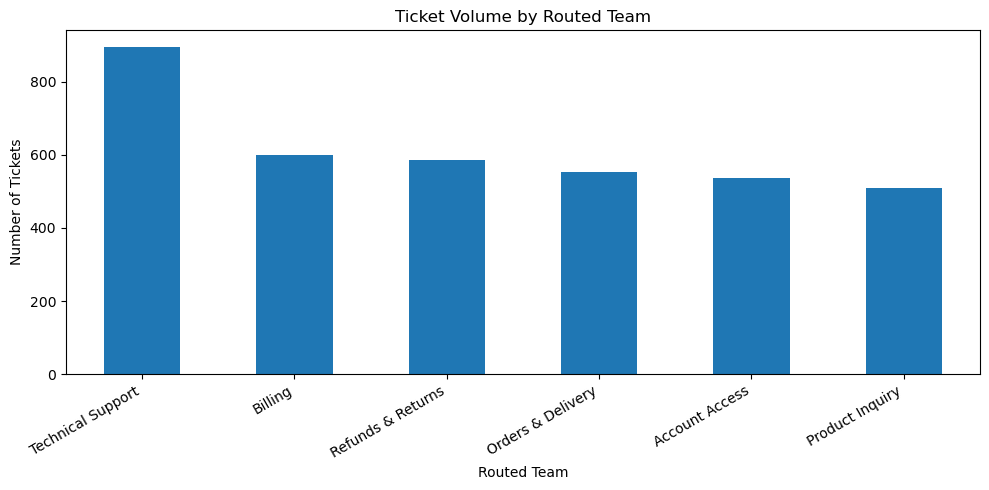

routed_team
Technical Support    896
Billing              600
Refunds & Returns    587
Orders & Delivery    554
Account Access       538
Product Inquiry      509
Name: count, dtype: Int64

In [17]:
team_counts = df["routed_team"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
team_counts.plot(kind="bar")
plt.title("Ticket Volume by Routed Team")
plt.xlabel("Routed Team")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "team_distribution_v2.png", dpi=200)
plt.show()

display(team_counts)

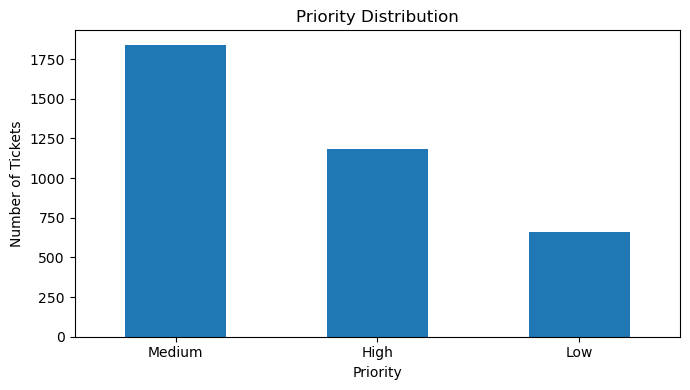

priority
Medium    1839
High      1183
Low        662
Name: count, dtype: Int64

In [18]:
priority_counts = df["priority"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
priority_counts.plot(kind="bar")
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "priority_distribution_v2.png", dpi=200)
plt.show()

display(priority_counts)

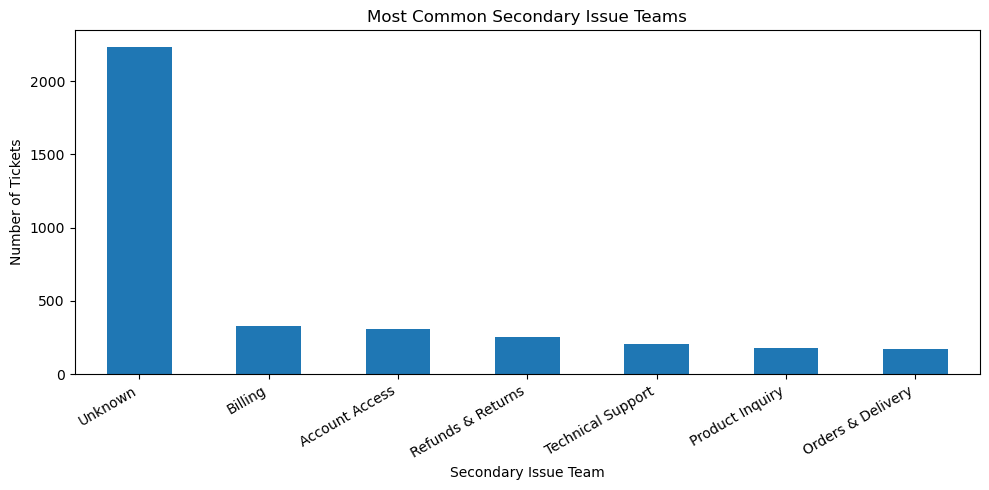

secondary_issue_team
Unknown              2236
Billing               328
Account Access        310
Refunds & Returns     252
Technical Support     209
Product Inquiry       180
Orders & Delivery     169
Name: count, dtype: Int64

In [19]:
secondary_counts = df["secondary_issue_team"].value_counts().head(10)

plt.figure(figsize=(10, 5))
secondary_counts.plot(kind="bar")
plt.title("Most Common Secondary Issue Teams")
plt.xlabel("Secondary Issue Team")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "secondary_issue_distribution_v2.png", dpi=200)
plt.show()

display(secondary_counts)

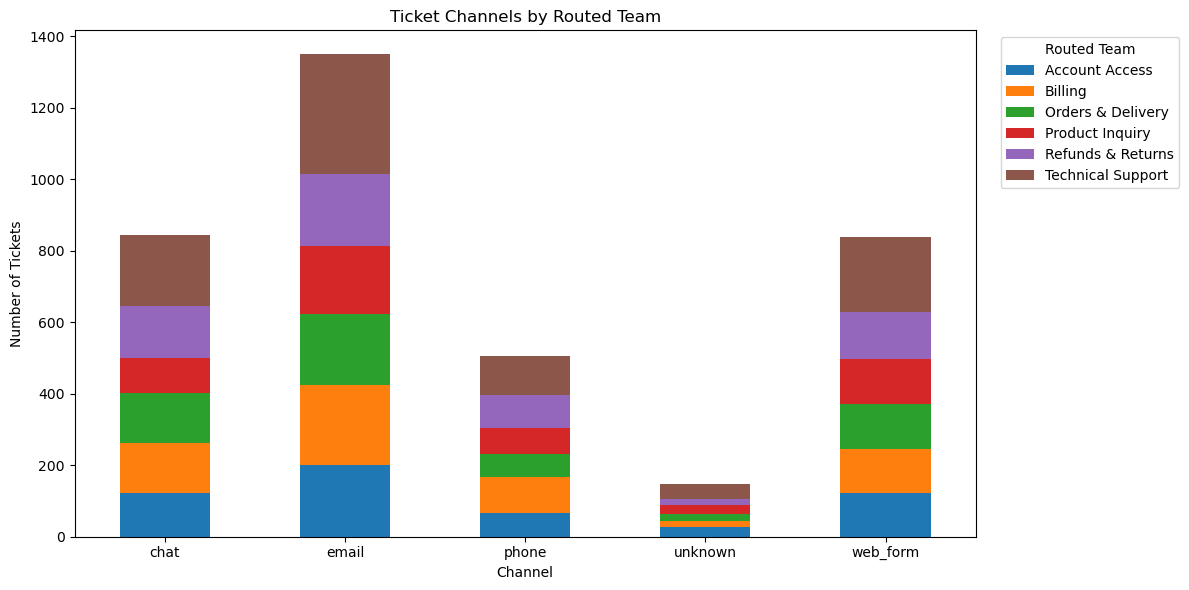

routed_team,Account Access,Billing,Orders & Delivery,Product Inquiry,Refunds & Returns,Technical Support
channel,,,,,,
chat,123,138,140,98,145,201
email,201,222,200,191,201,334
phone,67,100,65,71,92,110
unknown,26,17,21,23,18,41
web_form,121,123,128,126,131,210


In [20]:
channel_team_ct = pd.crosstab(df["channel"], df["routed_team"])

channel_team_ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Ticket Channels by Routed Team")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.legend(title="Routed Team", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "channel_by_team_v2.png", dpi=200)
plt.show()

display(channel_team_ct)

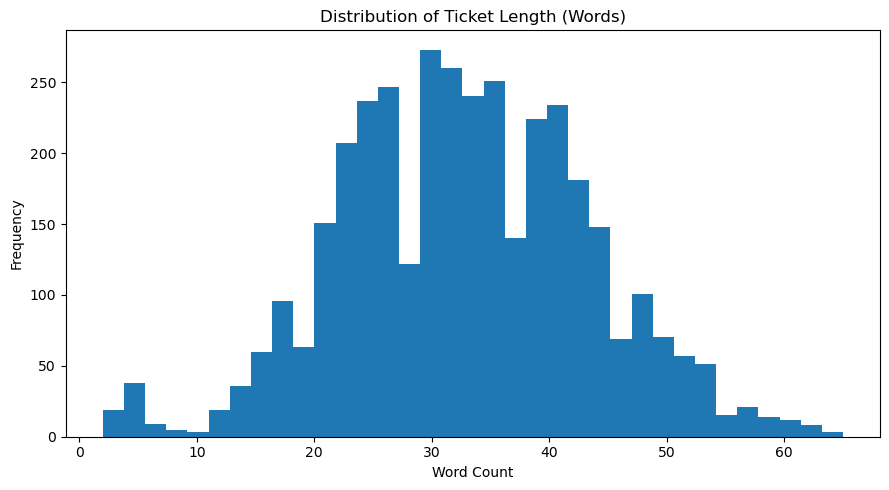

count    3684.000000
mean       32.703583
std        10.616335
min         2.000000
25%        25.000000
50%        32.000000
75%        40.000000
max        65.000000
Name: text_length_words, dtype: float64

In [21]:
plt.figure(figsize=(9, 5))
plt.hist(df["text_length_words"], bins=35)
plt.title("Distribution of Ticket Length (Words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_length_distribution_v2.png", dpi=200)
plt.show()

display(df["text_length_words"].describe())

<Figure size 1000x500 with 0 Axes>

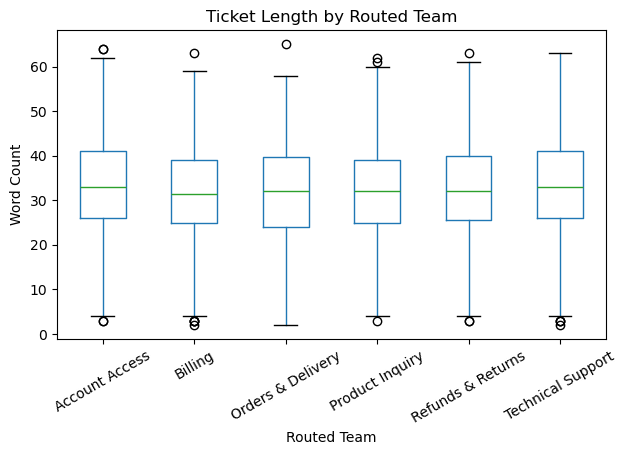

In [22]:
plt.figure(figsize=(10, 5))
df.boxplot(column="text_length_words", by="routed_team", grid=False, rot=30)
plt.title("Ticket Length by Routed Team")
plt.suptitle("")
plt.xlabel("Routed Team")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_length_by_team_v2.png", dpi=200)
plt.show()

## Inspect sample tickets

To verify realism, we inspect example tickets from each routed team.

This is useful for checking whether:
- the text sounds natural enough
- mixed-intent tickets exist
- classes are no longer separated by obvious rigid templates

In [23]:
sample_examples = (
    df.groupby("routed_team", group_keys=False)
    .apply(lambda x: x.sample(3, random_state=SEED) if len(x) >= 3 else x)
    [["routed_team", "secondary_issue_team", "priority", "channel", "product_area", "subject", "description"]]
    .sort_values("routed_team")
    .reset_index(drop=True)
)

display(sample_examples)

,routed_team,secondary_issue_team,priority,channel,product_area,subject,description
0,Account Access,Unknown,High,chat,Web App,Question about Web App,The login step keeps failing even though my details should be correct. I am using the web version. I would appreciate a quick response.
1,Account Access,Unknown,High,email,Web App,Need an update on this issue,This has become a problem for me. This looks like an acount access problem. It involves web app on my side. I do not know if this should go to billing or su...
2,Account Access,Unknown,Medium,phone,Web App,verification failed on my account,Can someone help with this? I cannot sign in to my account at the moment. I do not know if this should go to billing or support.
3,Billing,Account Access,High,chat,Subscription Plan,Need help with my account,"Good morning, The amount shown on the invoice looks wrong. It involves subscription plan on my side. Also, the verification step is failing and I need help...."
4,Billing,Unknown,Medium,web_form,Subscription Plan,Follow-up on my previous issue,There seems to be a problem with the payment on my acount. This has been going on since yesterday.
5,Billing,Refunds & Returns,High,web_form,Replacement Unit,Issue with recent order,"I noticed an unexpected charge and need clarification. It involves replacement unit on my side. At the same time, i need to return the item because it is no..."
6,Orders & Delivery,Refunds & Returns,High,web_form,Replacement Unit,Support request,"Can someone help with this? The package is missing and I need an update. Also, i need to return the item because it is not as expected. This is affecting my..."
7,Orders & Delivery,Unknown,High,email,Premium Device,Problem with recent activity,Can someone help with this? The package is missing and I need an update. This seems linked to my recent order.
8,Orders & Delivery,Refunds & Returns,High,web_form,Replacement Unit,URGENT - Issue with wrong item,Can someone help with this? There seems to be a delay with the shipment. This may also be related because i have not had an update on my refund yet. I was h...
9,Product Inquiry,Billing,Low,email,Subscription Plan,Help needed,This has become a problem for me. I need more information before making a decision. This may also be related because i am not sure why this payment failed. ...


## Key observations

This revised dataset differs from the earlier easy version in several important ways:

- tickets can mention more than one issue family
- subjects are often vague and not directly class-specific
- different teams share overlapping business vocabulary
- duplicate-like records and imperfect fields remain present
- the labels reflect dominant routing responsibility rather than perfectly isolated intent

These changes should produce a more realistic machine learning task and reduce the chance of unrealistically perfect performance.

## Next step

The next notebook will:
- load the cleaned revised dataset
- split the data into train and test sets
- apply TF-IDF feature extraction
- train baseline models
- compare results using Macro F1, Weighted F1, and Accuracy

If the revised dataset is working as intended, model scores should remain strong but become more realistic than the earlier perfect result.